# Lab 10 — Learning the XOR function with an MLP

**Aim:** implement the same small neural network in Keras, PyTorch, and low-level TensorFlow, and use XOR to study how learning rate, activation, hidden width, and epoch count change what the network learns.

- XOR is the textbook case of a function a single-layer perceptron cannot learn, so a hidden layer is not optional here.
- The same architecture (2 inputs, 4 hidden units, 1 sigmoid output) is built three times so the libraries can be compared on equal terms.
- The last part sweeps hyperparameters over several random seeds, because one run of a 4-point problem says very little on its own.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import layers

import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| PyTorch", torch.__version__)

TensorFlow 2.21.0 | Keras 3.15.1 | PyTorch 2.13.0


## Task 1 — The XOR dataset

- The dataset is the full truth table: 4 rows, both inputs binary, output 1 only when the inputs differ.
- There is no train/test split, because the 4 rows *are* the entire function. The question is whether the net can represent XOR, not whether it generalises to unseen points.

In [2]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("Input 1  Input 2  |  XOR")
for (a, b), t in zip(X, y):
    print(f"   {int(a)}        {int(b)}     |   {int(t[0])}")

Input 1  Input 2  |  XOR
   0        0     |   0
   0        1     |   1
   1        0     |   1
   1        1     |   0


### Why a single layer cannot do it

- Plotting the four points shows the two 1s sit on one diagonal and the two 0s on the other.
- Any straight line that keeps both 1s on the same side has to drag a 0 along with it, so the best a line can do is 3 of 4.

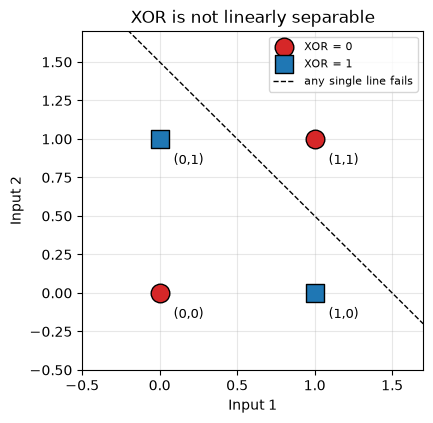

In [3]:
plt.figure(figsize=(4.4, 4.4))
for cls, color, marker in [(0, "#d62728", "o"), (1, "#1f77b4", "s")]:
    pts = X[y.ravel() == cls]
    plt.scatter(pts[:, 0], pts[:, 1], c=color, marker=marker, s=180,
                edgecolor="k", zorder=3, label=f"XOR = {cls}")
for xs, ys_, t in zip(X[:, 0], X[:, 1], y.ravel()):
    plt.annotate(f"({int(xs)},{int(ys_)})", (xs, ys_), textcoords="offset points",
                 xytext=(10, -18), fontsize=9)
xx = np.linspace(-0.5, 1.7, 10)
plt.plot(xx, 1.5 - xx, "k--", lw=1, label="any single line fails")
plt.xlim(-0.5, 1.7); plt.ylim(-0.5, 1.7)
plt.xlabel("Input 1"); plt.ylabel("Input 2")
plt.title("XOR is not linearly separable")
plt.legend(loc="upper right", fontsize=8)
plt.grid(alpha=0.3)
plt.show()

- Rather than assert it, fit a model with no hidden layer (logistic regression, i.e. a single sigmoid unit) and check the accuracy it reaches.

In [4]:
from sklearn.linear_model import LogisticRegression

linear = LogisticRegression().fit(X, y.ravel())
lin_pred = linear.predict(X)
print("Single-unit model predictions:", lin_pred)
print("Targets:                      ", y.ravel().astype(int))
print("Accuracy:", (lin_pred == y.ravel()).mean())

Single-unit model predictions: [0. 0. 0. 0.]
Targets:                       [0 1 1 0]
Accuracy: 0.5


**Observations**

- The single sigmoid unit predicts 0 for every input, 2 of 4 correct, which is what guessing gives.
- XOR is symmetric, so the pull from the two 1s and the two 0s cancels and the fit collapses to a constant output. Even the best possible line only reaches 3 of 4.

### Shared helper for decision boundaries

- Every implementation gets scored the same way: probabilities on a dense grid over the input square, then a contour at 0.5.
- The helper takes any function mapping an (N, 2) array to N probabilities, so the same code works for Keras, PyTorch, and raw TensorFlow.

In [5]:
def plot_boundary(predict_fn, title, ax=None):
    """Contour the predicted probability over the unit square and mark the 4 XOR points."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.6, 4.2))
    g = np.linspace(-0.25, 1.25, 200)
    gx, gy = np.meshgrid(g, g)
    grid = np.c_[gx.ravel(), gy.ravel()].astype(np.float32)
    zz = np.asarray(predict_fn(grid)).reshape(gx.shape)
    cf = ax.contourf(gx, gy, zz, levels=np.linspace(0, 1, 21), cmap="RdBu", alpha=0.8)
    ax.contour(gx, gy, zz, levels=[0.5], colors="k", linewidths=1.6)
    for cls, color, marker in [(0, "#d62728", "o"), (1, "#1f77b4", "s")]:
        pts = X[y.ravel() == cls]
        ax.scatter(pts[:, 0], pts[:, 1], c=color, marker=marker, s=150,
                   edgecolor="k", zorder=3, label=f"XOR = {cls}")
    ax.set_xlabel("Input 1"); ax.set_ylabel("Input 2"); ax.set_title(title)
    return cf, ax


def report(probs, name):
    """Print the truth table with predicted probabilities and rounded outputs."""
    probs = np.asarray(probs).ravel()
    pred = (probs > 0.5).astype(int)
    print(f"{name}\n In1  In2 | target |  prob  | pred")
    for (a, b), t, p, pr in zip(X, y.ravel(), probs, pred):
        print(f"  {int(a)}    {int(b)}  |   {int(t)}    | {p:.4f} |  {pr}")
    acc = (pred == y.ravel().astype(int)).mean()
    print(f" accuracy: {acc:.2f}")
    return acc

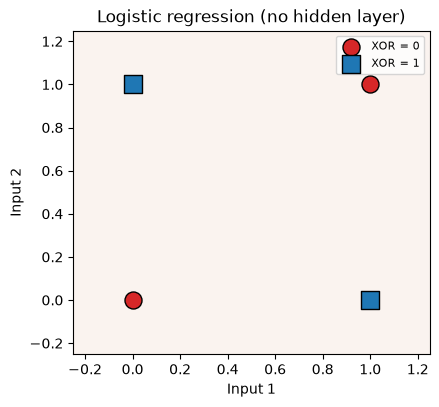

In [6]:
plot_boundary(lambda g: linear.predict_proba(g)[:, 1], "Logistic regression (no hidden layer)")
plt.legend(fontsize=8, loc="upper right")
plt.show()

**Observations**

- There is no 0.5 contour anywhere in the square: the model returns roughly the same probability everywhere.
- No amount of training moves this, because the model has no way to bend the boundary. That is the gap the hidden layer fills.

## Task 2 — Keras implementation

- Architecture: `Dense(4, relu)` then `Dense(1, sigmoid)`. Two hidden units are the theoretical minimum, but 4 gives the optimiser room to escape a bad initialisation.
- Loss is binary cross-entropy, the standard choice for a sigmoid output, and the optimiser is Adam at learning rate 0.05.
- All 4 samples fit in one batch, so `batch_size=4` means one gradient step per epoch.

In [7]:
keras.utils.set_random_seed(SEED)

keras_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="relu", name="hidden"),
    layers.Dense(1, activation="sigmoid", name="output"),
])
keras_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05),
                    loss="binary_crossentropy", metrics=["accuracy"])
keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

- The parameter count is small enough to check by hand: 2×4 + 4 weights in the hidden layer, 4×1 + 1 in the output, 17 total.

In [8]:
t0 = time.time()
history = keras_model.fit(X, y, epochs=1000, batch_size=4, verbose=0)
keras_time = time.time() - t0
print(f"Trained 1000 epochs in {keras_time:.2f}s")
print(f"Final loss: {history.history['loss'][-1]:.6f}")
first_perfect_keras = next((i + 1 for i, a in enumerate(history.history["accuracy"]) if a == 1.0), None)
print("First epoch with all 4 correct:", first_perfect_keras)

Trained 1000 epochs in 6.41s
Final loss: 0.000076
First epoch with all 4 correct: 3


In [9]:
keras_probs = keras_model.predict(X, verbose=0)
keras_acc = report(keras_probs, "Keras")

Keras
 In1  In2 | target |  prob  | pred
  0    0  |   0    | 0.0001 |  0
  0    1  |   1    | 0.9999 |  1
  1    0  |   1    | 0.9999 |  1
  1    1  |   0    | 0.0001 |  0
 accuracy: 1.00


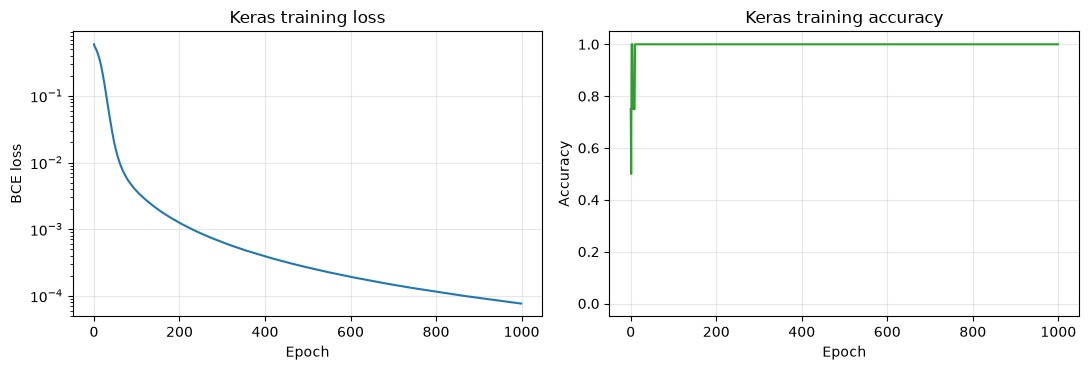

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(history.history["loss"], color="#1f77b4")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss"); axes[0].set_title("Keras training loss")
axes[0].set_yscale("log"); axes[0].grid(alpha=0.3)
axes[1].plot(history.history["accuracy"], color="#2ca02c")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Keras training accuracy")
axes[1].set_ylim(-0.05, 1.05); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

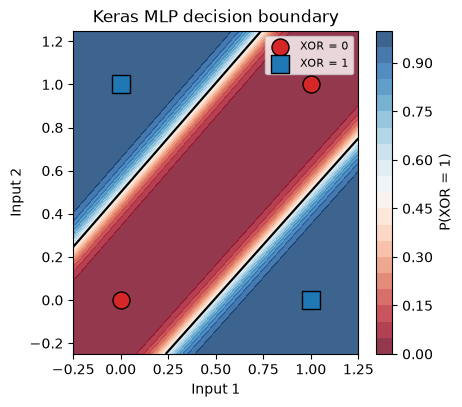

In [11]:
cf, ax = plot_boundary(lambda g: keras_model.predict(g, verbose=0).ravel(), "Keras MLP decision boundary")
plt.colorbar(cf, ax=ax, label="P(XOR = 1)")
ax.legend(fontsize=8, loc="upper right")
plt.show()

**Observations**

- All four probabilities land within 0.0001 of their targets, final loss 7.6e-5, accuracy 1.00.
- Accuracy was already 4/4 at epoch 3. The other 997 epochs only pushed the probabilities closer to 0 and 1, which is why the loss curve keeps falling after the accuracy curve flattens.
- The boundary is two parallel straight lines with a red band between them. ReLU makes the output piecewise linear, so the network cuts the plane with folds instead of drawing a curve.

## Task 3 — PyTorch implementation

- Same 2-4-1 network, but the training loop is written out: zero the gradients, forward, loss, backward, step.
- `BCEWithLogitsLoss` is used instead of a sigmoid layer plus `BCELoss`; it is the numerically stable version of the same thing, so the sigmoid is applied by hand at prediction time.

In [12]:
torch.manual_seed(SEED)

Xt = torch.tensor(X)
yt = torch.tensor(y)

torch_model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),   # logits; sigmoid folded into the loss
)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.05)

print(torch_model)
print("Trainable parameters:", sum(p.numel() for p in torch_model.parameters()))

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)
Trainable parameters: 17


In [13]:
torch_loss, torch_acc_hist = [], []

t0 = time.time()
for epoch in range(1000):
    optimizer.zero_grad()
    logits = torch_model(Xt)
    loss = criterion(logits, yt)
    loss.backward()
    optimizer.step()

    torch_loss.append(loss.item())
    with torch.no_grad():
        pred = (torch.sigmoid(logits) > 0.5).float()
        torch_acc_hist.append((pred == yt).float().mean().item())

torch_time = time.time() - t0
print(f"Trained 1000 epochs in {torch_time:.2f}s")
print(f"Final loss: {torch_loss[-1]:.6f}")
print("First epoch with all 4 correct:", next((i + 1 for i, a in enumerate(torch_acc_hist) if a == 1.0), None))

Trained 1000 epochs in 0.19s
Final loss: 0.000613
First epoch with all 4 correct: 40


In [14]:
def torch_predict(g):
    with torch.no_grad():
        return torch.sigmoid(torch_model(torch.tensor(g, dtype=torch.float32))).numpy().ravel()

torch_probs = torch_predict(X)
torch_acc = report(torch_probs, "PyTorch")

PyTorch
 In1  In2 | target |  prob  | pred
  0    0  |   0    | 0.0001 |  0
  0    1  |   1    | 0.9999 |  1
  1    0  |   1    | 0.9980 |  1
  1    1  |   0    | 0.0002 |  0
 accuracy: 1.00


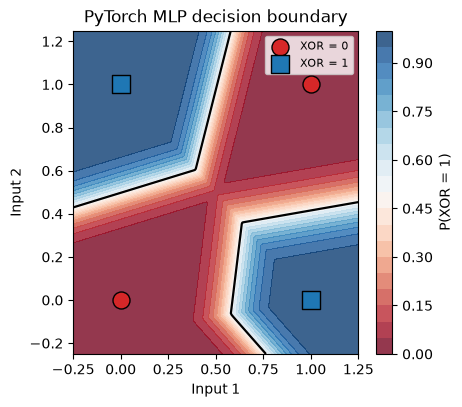

In [15]:
cf, ax = plot_boundary(torch_predict, "PyTorch MLP decision boundary")
plt.colorbar(cf, ax=ax, label="P(XOR = 1)")
ax.legend(fontsize=8, loc="upper right")
plt.show()

**Observations**

- Same 17 parameters, same outcome: all four correct, final loss 6.1e-4.
- It took 40 epochs to get all four right against 3 for Keras. Nothing about the maths differs; the two libraries just start from different random weights.
- The boundary is a kinked pair of lines meeting near the middle, not the parallel band Keras found. Four points do not pin down one solution.

## Task 4 — TensorFlow low-level API

- No `Sequential`, no `fit`. Weights are plain `tf.Variable`s, the forward pass is two `matmul`s, and `GradientTape` records the operations so the gradients can be pulled out.
- Glorot initialisation is used explicitly, since there is no layer object to do it. Adam is reused as an optimiser only to apply the gradients that the tape produced.

In [16]:
tf.random.set_seed(SEED)

init = tf.initializers.GlorotUniform(seed=SEED)
W1 = tf.Variable(init(shape=(2, 4)), name="W1")
b1 = tf.Variable(tf.zeros([4]), name="b1")
W2 = tf.Variable(init(shape=(4, 1)), name="W2")
b2 = tf.Variable(tf.zeros([1]), name="b2")
params = [W1, b1, W2, b2]

Xtf = tf.constant(X)
ytf = tf.constant(y)

def forward(inputs):
    hidden = tf.nn.relu(tf.matmul(inputs, W1) + b1)
    return tf.matmul(hidden, W2) + b2      # logits

tf_opt = tf.optimizers.Adam(learning_rate=0.05)
print("Variables:", [v.name for v in params], "->", sum(int(tf.size(v)) for v in params), "parameters")

Variables: ['W1:0', 'b1:0', 'W2:0', 'b2:0'] -> 17 parameters


In [17]:
tf_loss = []

t0 = time.time()
for epoch in range(1000):
    with tf.GradientTape() as tape:
        logits = forward(Xtf)
        loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=ytf, logits=logits))
    grads = tape.gradient(loss, params)
    tf_opt.apply_gradients(zip(grads, params))
    tf_loss.append(float(loss))

tf_time = time.time() - t0
print(f"Trained 1000 epochs in {tf_time:.2f}s")
print(f"Final loss: {tf_loss[-1]:.6f}")

Trained 1000 epochs in 3.92s
Final loss: 0.000448


In [18]:
def tf_predict(g):
    return tf.sigmoid(forward(tf.constant(g, dtype=tf.float32))).numpy().ravel()

tf_probs = tf_predict(X)
tf_acc = report(tf_probs, "TensorFlow (low-level)")

TensorFlow (low-level)
 In1  In2 | target |  prob  | pred
  0    0  |   0    | 0.0009 |  0
  0    1  |   1    | 0.9997 |  1
  1    0  |   1    | 0.9997 |  1
  1    1  |   0    | 0.0003 |  0
 accuracy: 1.00


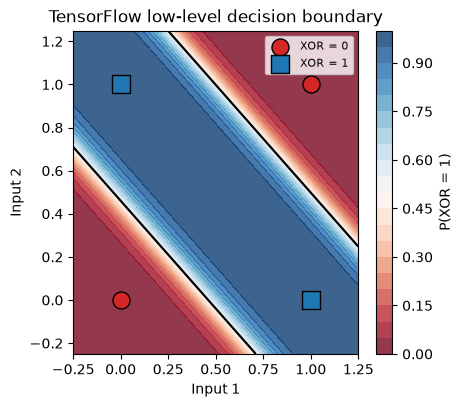

In [19]:
cf, ax = plot_boundary(tf_predict, "TensorFlow low-level decision boundary")
plt.colorbar(cf, ax=ax, label="P(XOR = 1)")
ax.legend(fontsize=8, loc="upper right")
plt.show()

**Observations**

- The hand-written forward pass and `GradientTape` reach the same place as `fit`: loss 4.5e-4 and all four outputs correct.
- Its boundary looks like the Keras one, as expected — identical maths, different API surface.
- Writing it out shows what `fit` packs away: one matmul per layer, one tape to record them, one call to apply the gradients.

## Task 5 — Comparing the three implementations

- Same architecture, same loss, same optimiser and learning rate, same number of epochs. Only the library differs, so the curves should land in the same place even if they do not overlap step for step.
- Different weight initialisations and RNG streams mean the paths differ; the final loss and accuracy are what should agree.

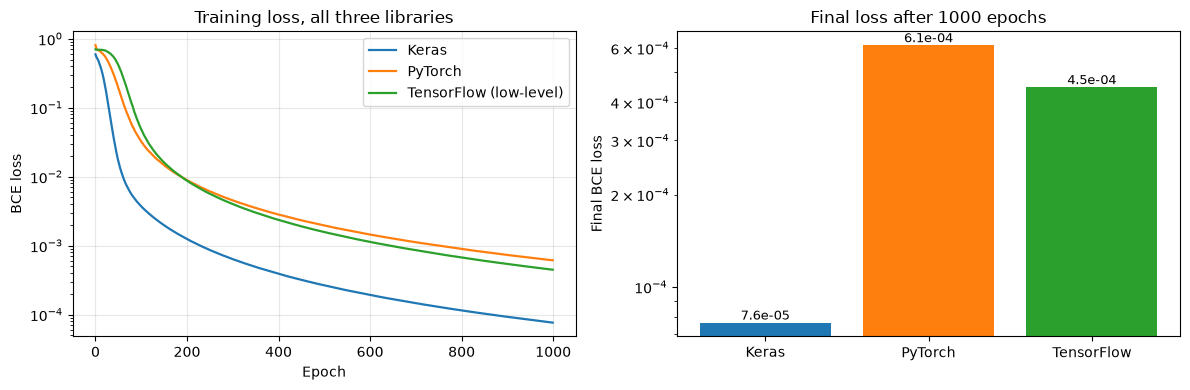

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="Keras", lw=1.6)
axes[0].plot(torch_loss, label="PyTorch", lw=1.6)
axes[0].plot(tf_loss, label="TensorFlow (low-level)", lw=1.6)
axes[0].set_yscale("log"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Training loss, all three libraries"); axes[0].legend(); axes[0].grid(alpha=0.3)

names = ["Keras", "PyTorch", "TensorFlow"]
finals = [history.history["loss"][-1], torch_loss[-1], tf_loss[-1]]
bars = axes[1].bar(names, finals, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_yscale("log"); axes[1].set_ylabel("Final BCE loss"); axes[1].set_title("Final loss after 1000 epochs")
for b, v in zip(bars, finals):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v:.1e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

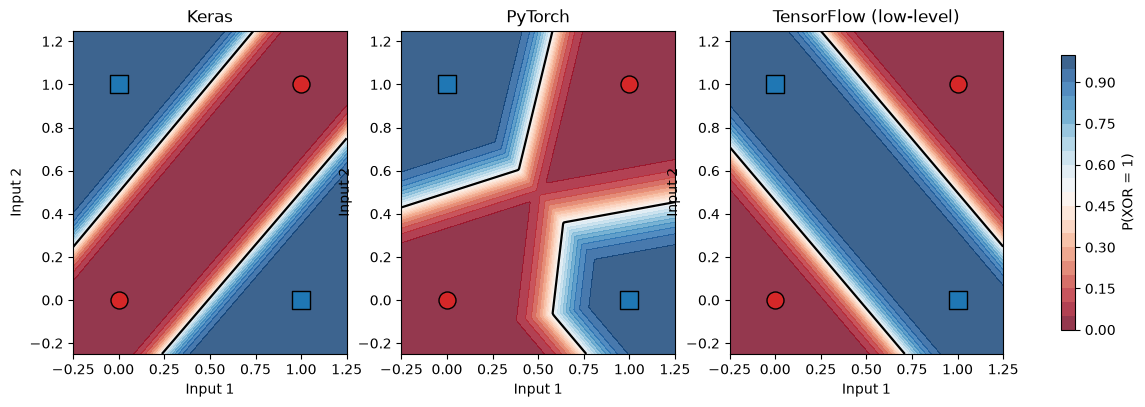

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_boundary(lambda g: keras_model.predict(g, verbose=0).ravel(), "Keras", axes[0])
plot_boundary(torch_predict, "PyTorch", axes[1])
cf, _ = plot_boundary(tf_predict, "TensorFlow (low-level)", axes[2])
fig.colorbar(cf, ax=axes, label="P(XOR = 1)", shrink=0.85)
plt.show()

In [22]:
print(f"{'Library':<24}{'Accuracy':>10}{'Final loss':>14}{'Time (s)':>11}")
for n, a, l, t in [("Keras", keras_acc, history.history['loss'][-1], keras_time),
                   ("PyTorch", torch_acc, torch_loss[-1], torch_time),
                   ("TensorFlow (low-level)", tf_acc, tf_loss[-1], tf_time)]:
    print(f"{n:<24}{a:>10.2f}{l:>14.2e}{t:>11.2f}")

Library                   Accuracy    Final loss   Time (s)
Keras                         1.00      7.65e-05       6.41
PyTorch                       1.00      6.13e-04       0.19
TensorFlow (low-level)        1.00      4.48e-04       3.92


**Observations**

- All three hit 100% accuracy with final losses inside one order of magnitude of each other. The library does not change the answer.
- Speed does differ: the PyTorch loop ran 1000 epochs in 0.19s against 6.41s for `keras.fit` and 3.92s for the TensorFlow loop. With a batch of 4 rows the per-step framework overhead is the whole cost, so this gap says nothing about performance on real data.
- The three boundary plots disagree everywhere except at the four training points. 17 parameters against 4 constraints leaves a lot of room.

## Task 6 — Effect of the hyperparameters

- All sweeps run in PyTorch, because a hand-written loop over 4 samples is far faster than `fit` and lets every configuration run on several seeds.
- Every configuration is repeated over 5 seeds and reported as a **success rate** (how often all 4 outputs come out right), since a single XOR run can succeed or fail purely on initialisation.

In [23]:
ACTS = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}

def train_xor(hidden=4, act="relu", lr=0.05, epochs=1000, seed=0, track_every=0):
    """Train one 2-h-1 MLP on XOR; return loss history, accuracy and optional accuracy checkpoints."""
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(2, hidden), ACTS[act](), nn.Linear(hidden, 1))
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossfn = nn.BCEWithLogitsLoss()

    losses, checkpoints = [], []
    for e in range(epochs):
        opt.zero_grad()
        logits = model(Xt)
        loss = lossfn(logits, yt)
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if track_every and (e + 1) % track_every == 0:
            with torch.no_grad():
                acc = (((torch.sigmoid(model(Xt)) > 0.5).float()) == yt).float().mean().item()
            checkpoints.append((e + 1, acc))

    with torch.no_grad():
        acc = (((torch.sigmoid(model(Xt)) > 0.5).float()) == yt).float().mean().item()
    return {"losses": losses, "acc": acc, "checkpoints": checkpoints, "model": model}


SEEDS = [0, 1, 2, 3, 4]

### 6a — Learning rate

- The learning rate sets how far each Adam step moves; too small and 1000 epochs are not enough, too large and the updates overshoot the minimum.
- Sweep six values spanning three orders of magnitude, holding everything else fixed at 4 hidden ReLU units.

In [24]:
lrs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
lr_results = {lr: [train_xor(lr=lr, seed=s) for s in SEEDS] for lr in lrs}

lr_success = [np.mean([r["acc"] == 1.0 for r in lr_results[lr]]) for lr in lrs]
lr_final = [np.mean([r["losses"][-1] for r in lr_results[lr]]) for lr in lrs]

for lr, s, f in zip(lrs, lr_success, lr_final):
    print(f"lr={lr:<7} success rate {s:.0%}   mean final loss {f:.4f}")

lr=0.001   success rate 60%   mean final loss 0.4330
lr=0.005   success rate 80%   mean final loss 0.1532
lr=0.01    success rate 100%   mean final loss 0.0044
lr=0.05    success rate 80%   mean final loss 0.1389
lr=0.1     success rate 60%   mean final loss 0.1910
lr=0.5     success rate 20%   mean final loss 0.4251


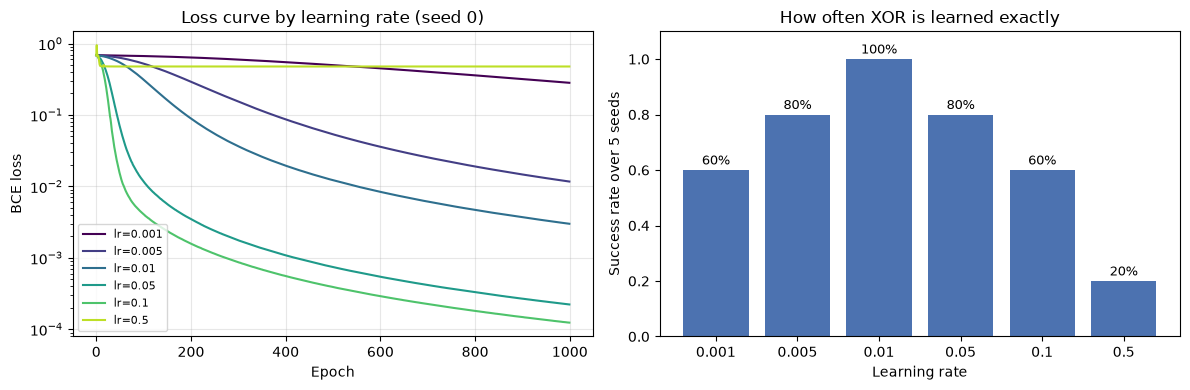

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(lrs)))
for lr, c in zip(lrs, cmap):
    axes[0].plot(lr_results[lr][0]["losses"], label=f"lr={lr}", color=c, lw=1.5)
axes[0].set_yscale("log"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss curve by learning rate (seed 0)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].bar([str(lr) for lr in lrs], lr_success, color="#4c72b0")
axes[1].set_xlabel("Learning rate"); axes[1].set_ylabel("Success rate over 5 seeds")
axes[1].set_ylim(0, 1.1); axes[1].set_title("How often XOR is learned exactly")
for i, s in enumerate(lr_success):
    axes[1].text(i, s + 0.02, f"{s:.0%}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

**Observations**

- 0.01 was the only value that learned XOR on all 5 seeds, with mean final loss 0.004.
- At 0.001 the curve is still descending when the 1000 epochs run out — the mean loss of 0.43 is unfinished training, not divergence.
- Above 0.01 reliability drops off: 0.5 worked on 1 seed out of 5 and its loss curve rattles instead of settling.
- The trend is not monotone in either direction, and the mean loss is a blunt summary — a failed run parks at ~0.69 and drags the average up on its own.

### 6b — Activation function

- The hidden activation is what makes the network non-linear; without it, stacking two linear layers collapses back into one and XOR stays out of reach.
- Compare ReLU, tanh, and sigmoid in the hidden layer, everything else fixed.

In [26]:
acts = ["relu", "tanh", "sigmoid"]
act_results = {a: [train_xor(act=a, seed=s) for s in SEEDS] for a in acts}
act_success = [np.mean([r["acc"] == 1.0 for r in act_results[a]]) for a in acts]

for a, s in zip(acts, act_success):
    mean_loss = np.mean([r["losses"][-1] for r in act_results[a]])
    print(f"{a:<8} success rate {s:.0%}   mean final loss {mean_loss:.4f}")

relu     success rate 80%   mean final loss 0.1389
tanh     success rate 80%   mean final loss 0.0696
sigmoid  success rate 80%   mean final loss 0.0708


In [27]:
# a linear "activation" is the control case: two stacked linear layers
torch.manual_seed(0)
lin_net = nn.Sequential(nn.Linear(2, 4), nn.Identity(), nn.Linear(4, 1))
lin_opt = torch.optim.Adam(lin_net.parameters(), lr=0.05)
lin_lossfn = nn.BCEWithLogitsLoss()
lin_losses = []
for e in range(1000):
    lin_opt.zero_grad()
    l = lin_lossfn(lin_net(Xt), yt)
    l.backward(); lin_opt.step(); lin_losses.append(l.item())
with torch.no_grad():
    lin_acc = (((torch.sigmoid(lin_net(Xt)) > 0.5).float()) == yt).float().mean().item()
print(f"no activation (linear): final loss {lin_losses[-1]:.4f}, accuracy {lin_acc:.2f}")

no activation (linear): final loss 0.6931, accuracy 0.25


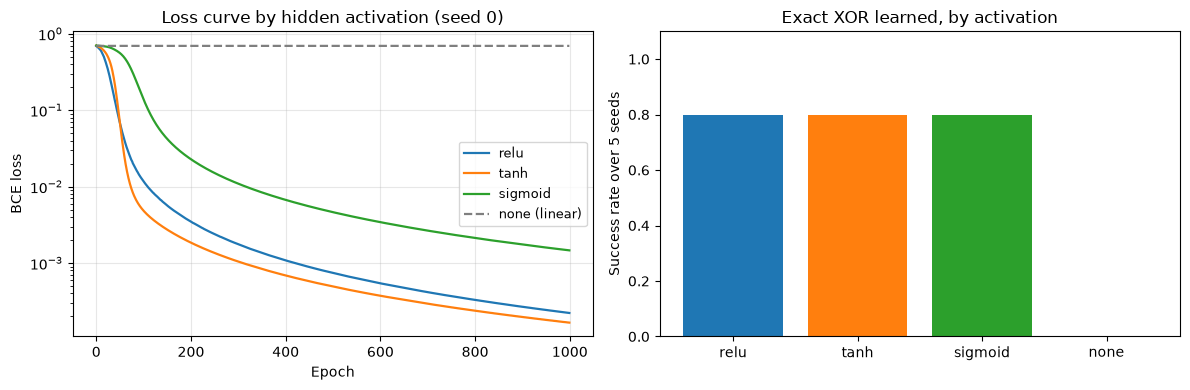

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for a, c in zip(acts, ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    axes[0].plot(act_results[a][0]["losses"], label=a, color=c, lw=1.6)
axes[0].plot(lin_losses, label="none (linear)", color="#7f7f7f", ls="--", lw=1.6)
axes[0].set_yscale("log"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss curve by hidden activation (seed 0)"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].bar(acts + ["none"], act_success + [lin_acc == 1.0], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#7f7f7f"])
axes[1].set_ylabel("Success rate over 5 seeds"); axes[1].set_ylim(0, 1.1)
axes[1].set_title("Exact XOR learned, by activation")
plt.tight_layout(); plt.show()

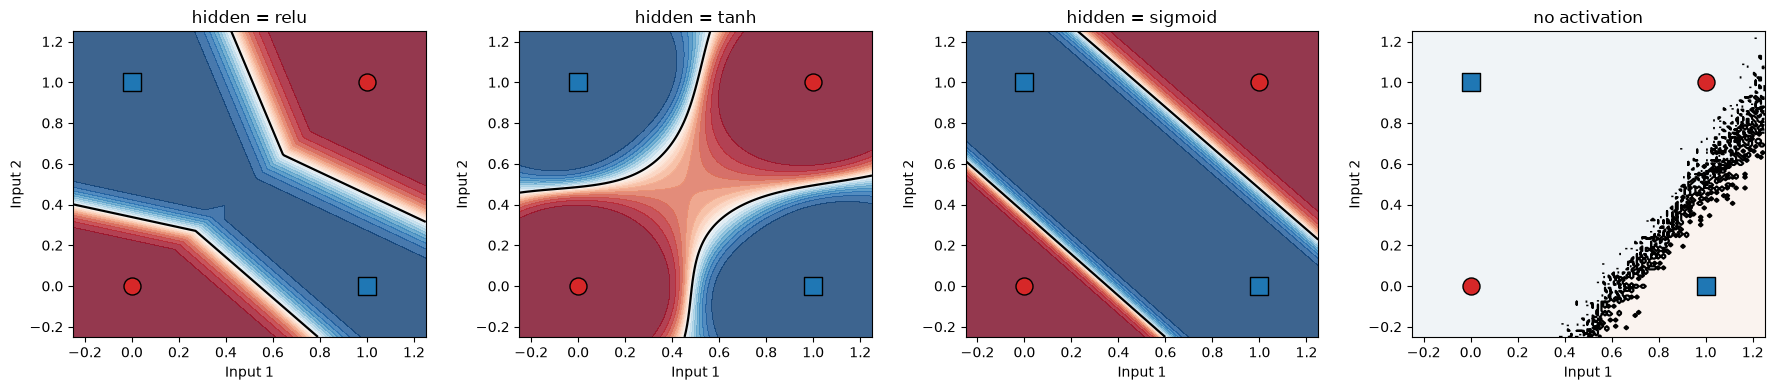

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, a in zip(axes, acts):
    m = act_results[a][0]["model"]
    fn = lambda g, m=m: torch.sigmoid(m(torch.tensor(g, dtype=torch.float32))).detach().numpy().ravel()
    plot_boundary(fn, f"hidden = {a}", ax)
fn_lin = lambda g: torch.sigmoid(lin_net(torch.tensor(g, dtype=torch.float32))).detach().numpy().ravel()
plot_boundary(fn_lin, "no activation", axes[3])
plt.tight_layout(); plt.show()

**Observations**

- ReLU, tanh, and sigmoid all reached 80% success, so at this size the activation decides the shape of the solution more than whether one is found.
- tanh and sigmoid finished at lower mean loss (0.070) than ReLU (0.139). A saturating unit can always recover; a ReLU whose input stays negative gets exactly zero gradient and is done for good.
- The boundaries look nothing alike: tanh draws a smooth X through the centre, sigmoid a wide band, ReLU straight folds.
- With no activation the loss sits at 0.6931 from start to finish. That is ln 2, the loss of predicting 0.5 for everything, because two stacked linear layers are still one linear map. The blank fourth panel is that constant surface — the speckle is the contour routine hunting for a 0.5 crossing on a flat field.

### 6c — Number of hidden neurons

- Two hidden units are enough to represent XOR in theory, so this sweep is about how much slack the optimiser needs in practice.
- Widths of 1, 2, 3, 4, 8, and 16 are each trained over 5 seeds with ReLU.

In [30]:
widths = [1, 2, 3, 4, 8, 16]
w_results = {h: [train_xor(hidden=h, seed=s) for s in SEEDS] for h in widths}
w_success = [np.mean([r["acc"] == 1.0 for r in w_results[h]]) for h in widths]
w_acc = [np.mean([r["acc"] for r in w_results[h]]) for h in widths]

for h, s, a in zip(widths, w_success, w_acc):
    print(f"hidden={h:<3} success rate {s:.0%}   mean accuracy {a:.2f}")

hidden=1   success rate 0%   mean accuracy 0.55
hidden=2   success rate 20%   mean accuracy 0.65
hidden=3   success rate 20%   mean accuracy 0.75
hidden=4   success rate 80%   mean accuracy 0.90
hidden=8   success rate 100%   mean accuracy 1.00
hidden=16  success rate 100%   mean accuracy 1.00


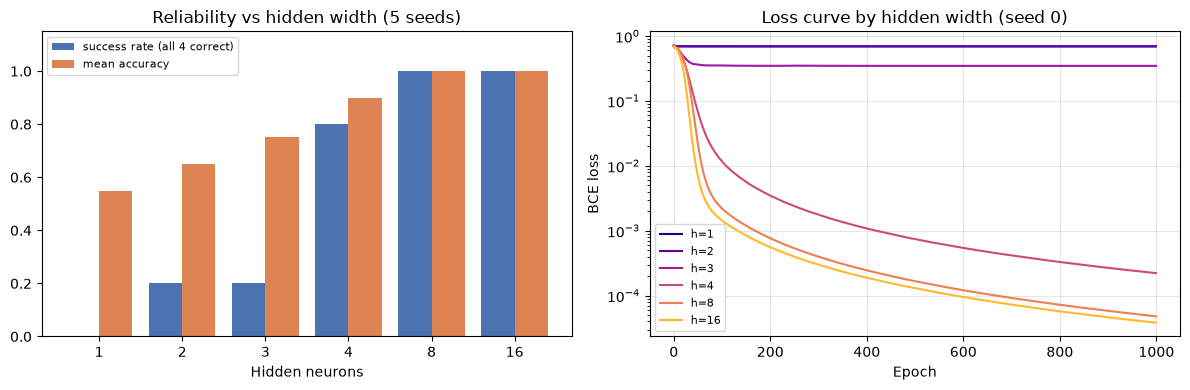

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(widths))
axes[0].bar(x - 0.2, w_success, 0.4, label="success rate (all 4 correct)", color="#4c72b0")
axes[0].bar(x + 0.2, w_acc, 0.4, label="mean accuracy", color="#dd8452")
axes[0].set_xticks(x); axes[0].set_xticklabels(widths)
axes[0].set_xlabel("Hidden neurons"); axes[0].set_ylim(0, 1.15); axes[0].legend(fontsize=8)
axes[0].set_title("Reliability vs hidden width (5 seeds)")

for h, c in zip(widths, plt.cm.plasma(np.linspace(0, 0.85, len(widths)))):
    axes[1].plot(w_results[h][0]["losses"], label=f"h={h}", color=c, lw=1.5)
axes[1].set_yscale("log"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("BCE loss")
axes[1].set_title("Loss curve by hidden width (seed 0)"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

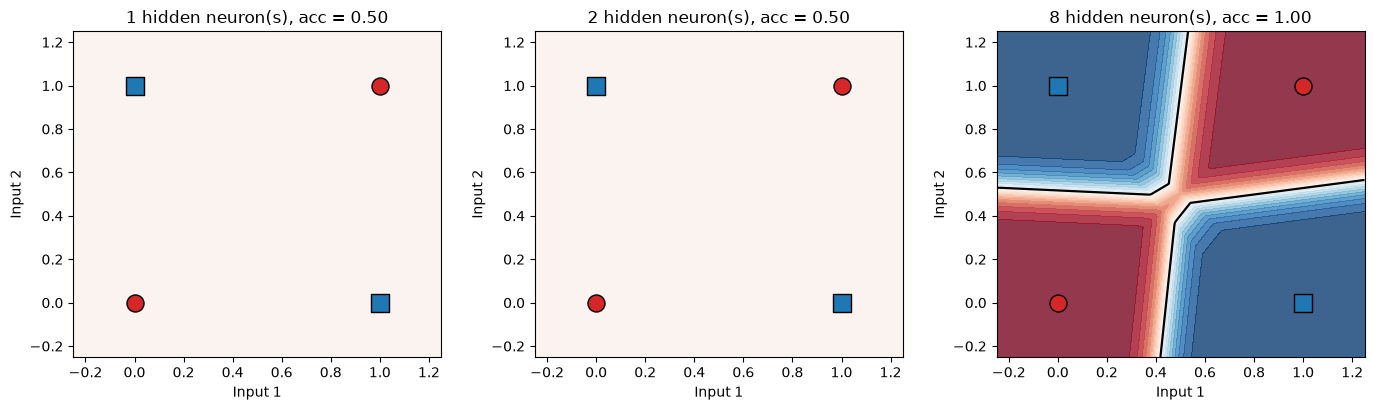

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, h in zip(axes, [1, 2, 8]):
    m = w_results[h][0]["model"]
    fn = lambda g, m=m: torch.sigmoid(m(torch.tensor(g, dtype=torch.float32))).detach().numpy().ravel()
    plot_boundary(fn, f"{h} hidden neuron(s), acc = {w_results[h][0]['acc']:.2f}", ax)
plt.tight_layout(); plt.show()

**Observations**

- 1 neuron never worked (0/5), 2 and 3 worked on 1 seed out of 5, and 8 and 16 worked on all 5.
- One unit cannot represent XOR at all. Two can, but only when the initialisation happens to cooperate, which is the gap between theory and the 20% here.
- The failures are dead ReLUs: every hidden output is 0 for all four inputs, so every gradient is 0 and the run is frozen at a constant 0.5 output. Those are the flat pink panels below.
- Extra width does not add capacity that XOR needs. It adds more chances that at least one unit starts somewhere useful.

### 6d — Number of epochs

- With 4 samples in one batch, an epoch is a single gradient step, so "epochs" here is literally the number of updates.
- Accuracy is checked every 25 epochs to see when the network flips from wrong to right, and whether more training past that point buys anything.

In [33]:
epoch_runs = [train_xor(lr=0.05, epochs=2000, seed=s, track_every=25) for s in SEEDS]

steps = [e for e, _ in epoch_runs[0]["checkpoints"]]
acc_matrix = np.array([[a for _, a in r["checkpoints"]] for r in epoch_runs])
mean_acc = acc_matrix.mean(axis=0)

first_perfect = []
for r in epoch_runs:
    hit = [e for e, a in r["checkpoints"] if a == 1.0]
    first_perfect.append(hit[0] if hit else None)
print("First epoch with all 4 correct, per seed:", first_perfect)

First epoch with all 4 correct, per seed: [25, 25, None, 50, 50]


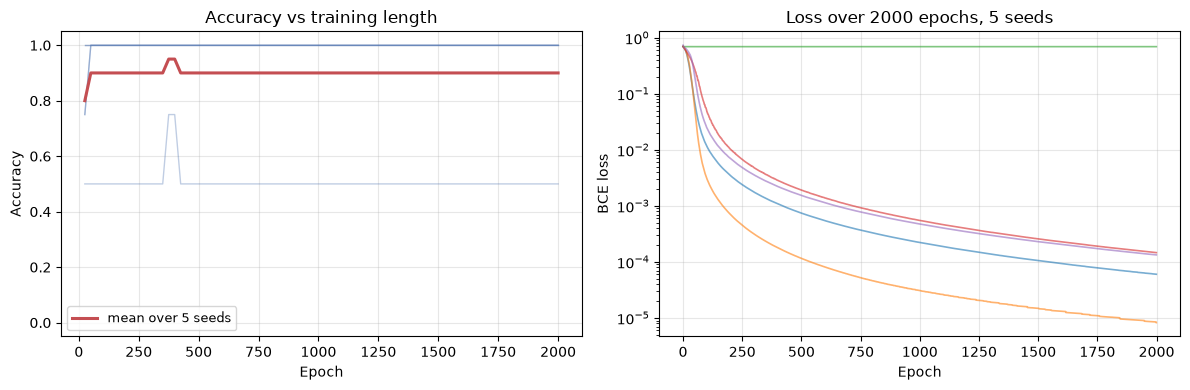

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, r in enumerate(epoch_runs):
    axes[0].plot(steps, [a for _, a in r["checkpoints"]], alpha=0.35, lw=1, color="#4c72b0")
axes[0].plot(steps, mean_acc, color="#c44e52", lw=2.2, label="mean over 5 seeds")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title("Accuracy vs training length"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

for r in epoch_runs:
    axes[1].plot(r["losses"], alpha=0.6, lw=1.2)
axes[1].set_yscale("log"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("BCE loss")
axes[1].set_title("Loss over 2000 epochs, 5 seeds"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Observations**

- 4 of the 5 seeds had all four outputs right by epoch 50 and never changed after that. The remaining 1950 epochs only cut the loss from ~1e-2 to ~1e-4.
- Classification finishes long before the loss does. Training past that point buys confident probabilities, not correctness.
- The fifth seed is flat at 0.693 from the first step. Its gradients are exactly zero (3 of its 4 ReLUs are dead and the surviving unit's output weight is ~0), so more epochs cannot move it.
- Epochs fix a network that is still converging. They do nothing for one that is stuck, which needs a different seed, a different activation, or more units.

### What the hidden layer actually does

- The hidden layer re-maps the four points into a new space; the output unit is still just a single linear classifier working on that space.
- Plotting the 2 hidden activations of a trained 2-neuron tanh network shows the two XOR = 0 points collapsing onto the same corner, which is exactly what makes a line work again.

2-neuron tanh net accuracy: 1.00
hidden activations per input:
  (0,0) -> [-0.986, -0.972]   target 0
  (0,1) -> [+0.987, -1.000]   target 1
  (1,0) -> [-1.000, +0.984]   target 1
  (1,1) -> [-0.988, -0.987]   target 0


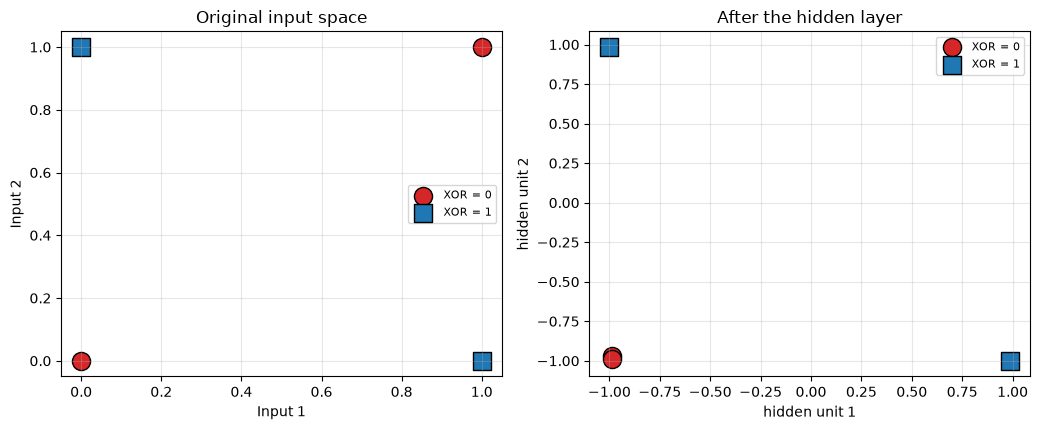

In [35]:
h2 = train_xor(hidden=2, act="tanh", lr=0.05, epochs=3000, seed=0)
print(f"2-neuron tanh net accuracy: {h2['acc']:.2f}")
print("hidden activations per input:")
for (a, b), t, h in zip(X, y.ravel(), h2["model"][1](h2["model"][0](Xt)).detach().numpy()):
    print(f"  ({int(a)},{int(b)}) -> [{h[0]:+.3f}, {h[1]:+.3f}]   target {int(t)}")

with torch.no_grad():
    hidden_out = h2["model"][1](h2["model"][0](Xt)).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for cls, color, marker in [(0, "#d62728", "o"), (1, "#1f77b4", "s")]:
    pts = X[y.ravel() == cls]
    axes[0].scatter(pts[:, 0], pts[:, 1], c=color, marker=marker, s=170, edgecolor="k", label=f"XOR = {cls}")
    hp = hidden_out[y.ravel() == cls]
    axes[1].scatter(hp[:, 0], hp[:, 1], c=color, marker=marker, s=170, edgecolor="k", label=f"XOR = {cls}")
axes[0].set_title("Original input space"); axes[0].set_xlabel("Input 1"); axes[0].set_ylabel("Input 2")
axes[1].set_title("After the hidden layer"); axes[1].set_xlabel("hidden unit 1"); axes[1].set_ylabel("hidden unit 2")
for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Observations**

- The two XOR = 0 inputs both land near (-1, -1) in hidden space, while (0,1) and (1,0) go to opposite corners at (+1, -1) and (-1, +1).
- Once the two 0s sit on top of each other, a single straight line separates them from the two 1s, which is all the output unit can do anyway.
- That is the whole job of the hidden layer: change coordinates until the problem is linear again.

## Inference

- All three libraries learned XOR exactly, with the same 2-4-1 network, the same 17 parameters, and the same loss and optimiser. What changed was how much is written by hand: three lines in Keras, an explicit loop in PyTorch, variables and a tape in TensorFlow.
- The hand-written PyTorch loop ran 34× faster than `keras.fit` here (0.19s vs 6.41s), which is a statement about framework overhead on a 4-row batch, not about the libraries in general.
- The hidden layer plus a non-linear activation is the part that matters. Strip the activation and the loss parks at ln 2 = 0.693 forever, whatever the learning rate or epoch count.
- Learning rate had the sharpest effect of the hyperparameters swept: 100% success at 0.01, 20% at 0.5, with slow-but-improving curves below and unstable ones above.
- Width buys reliability rather than capacity. Two hidden units can represent XOR but only got there on 1 seed in 5; eight units got there every time.
- Most of the failures were dead ReLUs frozen at a constant 0.5 output with zero gradient, not slow learning. Worth telling apart before throwing epochs at a model that has stopped moving.
- The three implementations agree on the truth table and disagree on the shape of the boundary between the points. With 4 samples and 17 parameters, "it learned XOR" only means it is right where it was told.